# UMAP — 流形降维与密度导向候选体筛选

**核心思路：** UMAP 相比 t-SNE 更好地保留全局流形结构。在 UMAP 嵌入空间中，已知 CN 星形成高密度区域，通过核密度估计 (KDE) 可以找到流形上延伸到未标记区域的 CN 星聚集区。

**与 Label Spreading 的关系：**
- Label Spreading = 在**原空间**的 KNN 图上传播标签
- UMAP = 在**低维嵌入**空间中做密度导向筛选
- 两者互补：UMAP 可视化更直观，Label Spreading 数学更严格


## 1. 环境配置与数据加载

In [1]:
import sys, os, time, warnings
from pathlib import Path
_PROJECT_ROOT = Path(os.getcwd())
for _ in range(5):
    if (_PROJECT_ROOT / "LabelSpreading").exists() and (_PROJECT_ROOT / "Data").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams.update({'font.size': 10})
import seaborn as sns; sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

from data_loader import ensure_cache
from LabelSpreading.umap_utils import run_umap_pipeline
from LabelSpreading.graph_utils import compute_cluster_zscore

data = ensure_cache()
X_clean = data['X_clean']
stars_clean = data['stars_clean']
feature_df = data['feature_df']
common_wave = data['common_wave']

known_mask = stars_clean['label'].values == 1
unlabeled_mask = stars_clean['label'].values == -1
n_known = known_mask.sum()
n_unl = unlabeled_mask.sum()

print(f"Data: {X_clean.shape[0]:,} stars, {n_known} known CN, {n_unl:,} unlabeled")

从 LabelSpreading 本地缓存加载...
  X_clean: (33565, 700)
  stars_clean: 33565 rows
  feature_df: (33565, 20)
  Known CN stars: 73
Data: 33,565 stars, 73 known CN, 33,492 unlabeled


## 2. 运行 UMAP + 密度估计

In [2]:
print("Running UMAP pipeline...")
result = run_umap_pipeline(
    X_clean, stars_clean,
    n_neighbors=30,
    min_dist=0.1,
    top_n=200,
    verbose=True,
)

embedding = result['embedding']
density = result['density']
candidates = result['candidate_indices']

print(f"\nUMAP embedding shape: {embedding.shape}")
print(f"Candidate count: {len(candidates)}")


Running UMAP pipeline...
UMAP Pipeline: 33,565 stars, 73 known CN, n_neighbors=30
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed May 27 01:10:45 2026 Construct fuzzy simplicial set
Wed May 27 01:10:45 2026 Finding Nearest Neighbors
Wed May 27 01:10:45 2026 Building RP forest with 14 trees
Wed May 27 01:10:53 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	Stopping threshold met -- exiting after 6 iterations
Wed May 27 01:11:13 2026 Finished Nearest Neighbor Search
Wed May 27 01:11:17 2026 Construct embedding


Epochs completed:   2%| ▏          4/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [00:02]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:19]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:21]


Wed May 27 01:11:40 2026 Finished embedding
UMAP embedding: 55.6s  shape=(33565, 2)
Candidates selected: 147
  Density range (candidates): 0.6396 - 2.6906
  Density range (known CN):   0.4437 - 2.6223

UMAP embedding shape: (33565, 2)
Candidate count: 147


## 3. UMAP 嵌入空间可视化（多视图）

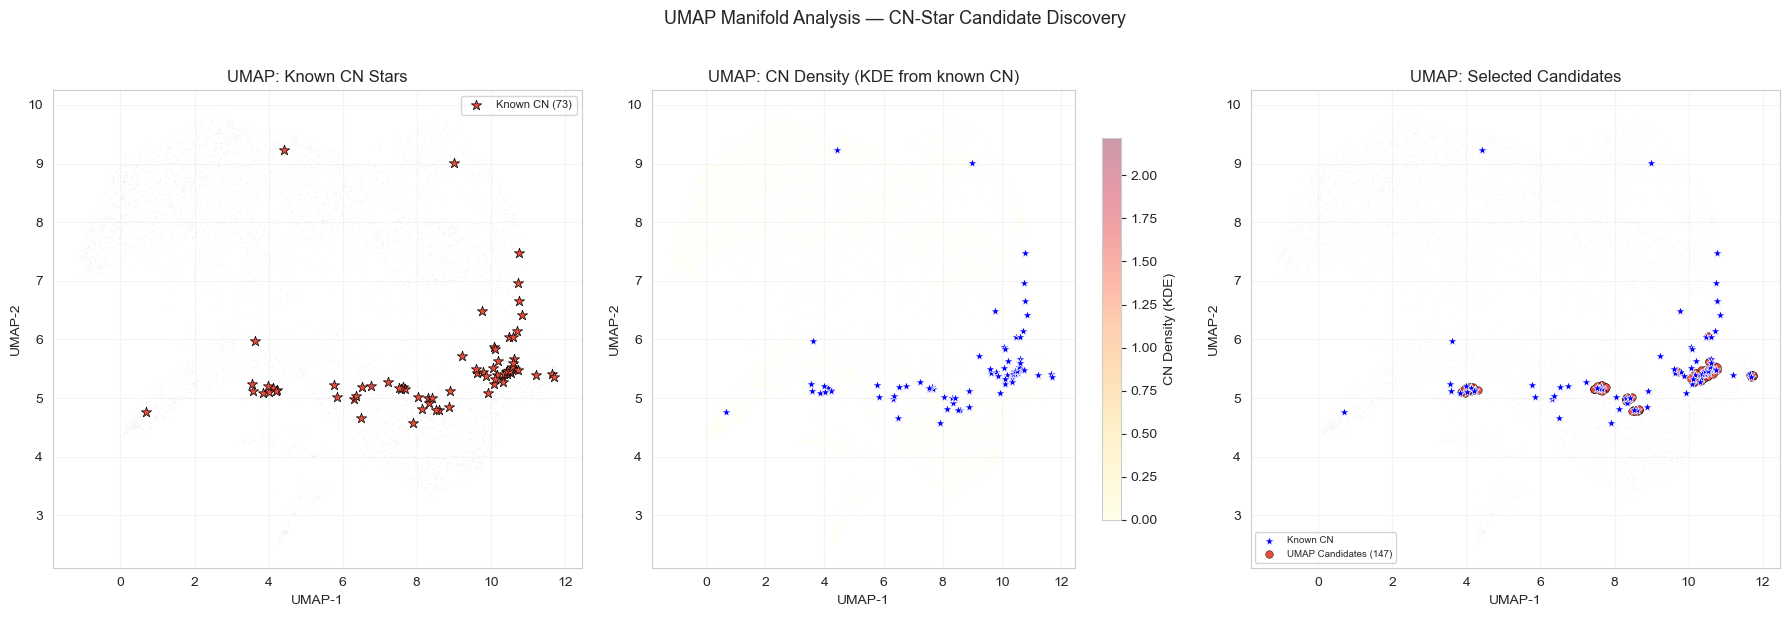

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (a) Known CN stars highlighted
ax = axes[0]
rng = np.random.RandomState(42)
bg = rng.choice(np.where(unlabeled_mask)[0], 5000, replace=False)
ax.scatter(embedding[bg, 0], embedding[bg, 1], s=1, c='#e0e0e0', alpha=0.3,
           edgecolors='none', rasterized=True)
ax.scatter(embedding[known_mask, 0], embedding[known_mask, 1],
           s=60, c='#e74c3c', marker='*', edgecolors='black', linewidth=0.5,
           label=f'Known CN ({n_known})', zorder=3)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('UMAP: Known CN Stars')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# (b) Density heatmap (KDE based on known CN)
ax = axes[1]
sc = ax.scatter(embedding[bg, 0], embedding[bg, 1], s=1, c=density[bg],
                cmap='YlOrRd', alpha=0.4, vmin=0, edgecolors='none', rasterized=True)
ax.scatter(embedding[known_mask, 0], embedding[known_mask, 1],
           s=50, c='blue', marker='*', edgecolors='white', linewidth=0.5, zorder=3)
cbar = plt.colorbar(sc, ax=ax, label='CN Density (KDE)', shrink=0.8)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('UMAP: CN Density (KDE from known CN)')
ax.grid(alpha=0.2)

# (c) Candidates highlighted
ax = axes[2]
ax.scatter(embedding[bg, 0], embedding[bg, 1], s=1, c='#e0e0e0', alpha=0.2,
           edgecolors='none', rasterized=True)
ax.scatter(embedding[known_mask, 0], embedding[known_mask, 1],
           s=50, c='blue', marker='*', edgecolors='white', linewidth=0.5,
           label=f'Known CN', zorder=3)
ax.scatter(embedding[candidates, 0], embedding[candidates, 1],
           s=30, c='#e74c3c', edgecolors='black', linewidth=0.3,
           label=f'UMAP Candidates ({len(candidates)})', zorder=2)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('UMAP: Selected Candidates')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

fig.suptitle('UMAP Manifold Analysis — CN-Star Candidate Discovery', fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/umap_embedding.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. UMAP 候选体光谱（前 12 颗）

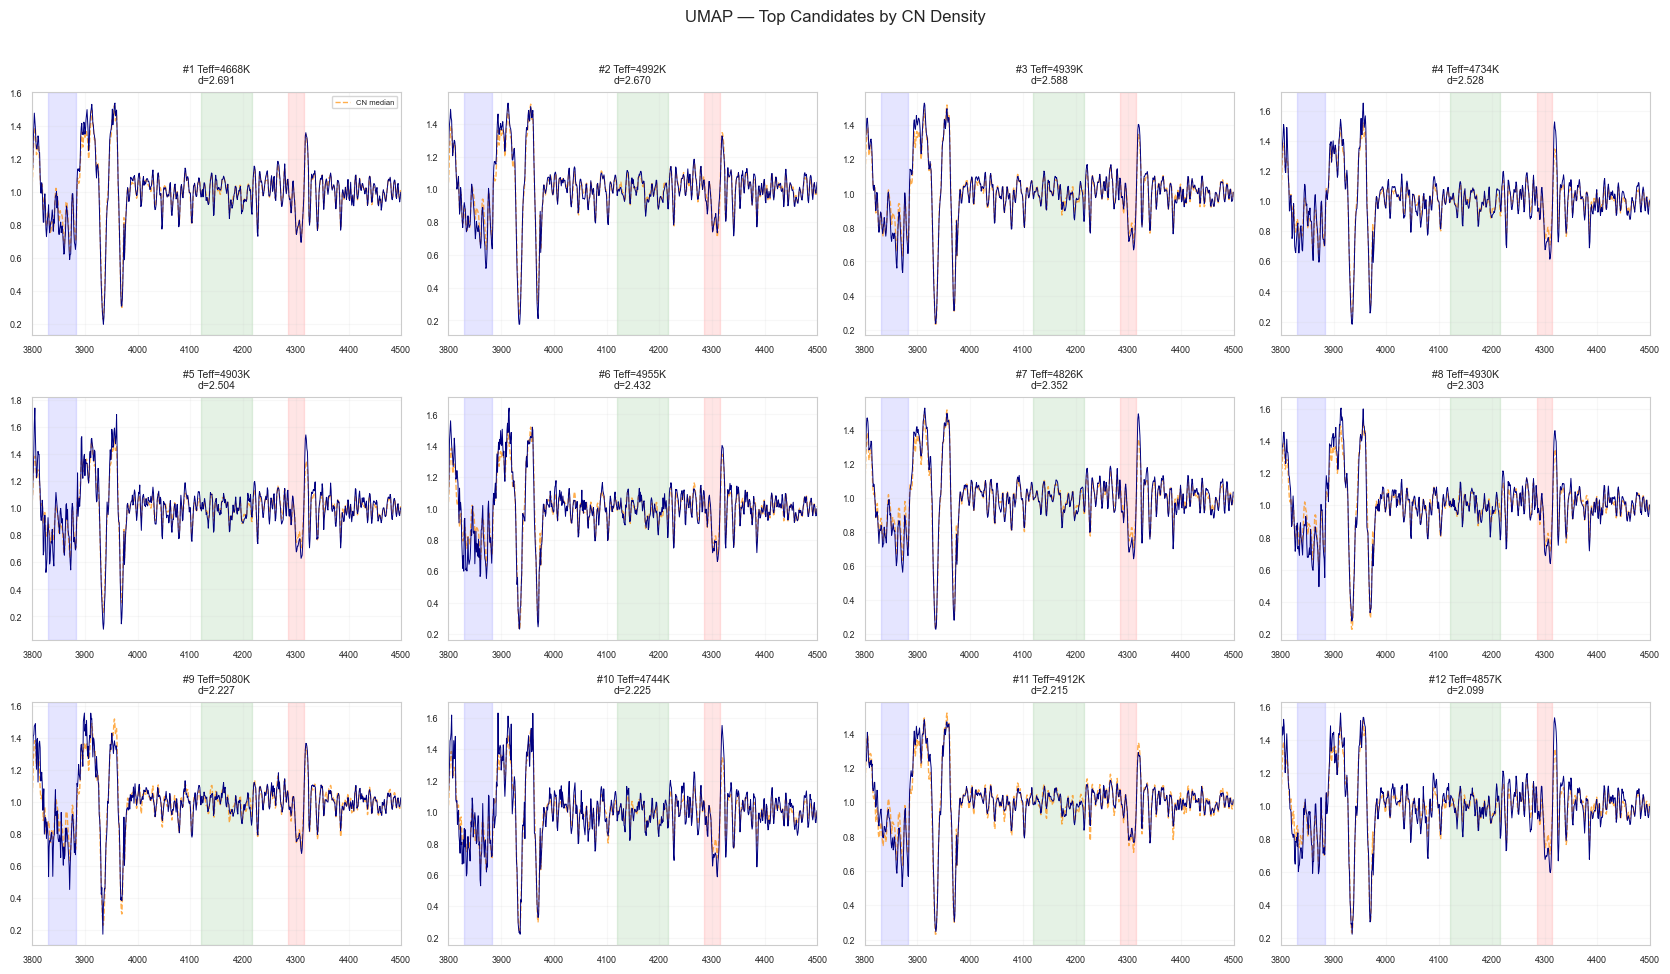

In [4]:
# Sort candidates by density
cand_order = np.argsort(density[candidates])[::-1]
n_show = min(12, len(candidates))
show_indices = candidates[cand_order[:n_show]]

# Known CN median
known_cn_median = np.nanmedian(X_clean[known_mask], axis=0)

n_cols = 4; n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 3.2*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else [axes]

for i in range(n_show):
    ax = axes_flat[i]
    idx = show_indices[i]
    flux = X_clean[idx]
    star = stars_clean.iloc[idx]
    teff = star['teff']

    ax.plot(common_wave, known_cn_median, color='darkorange', linewidth=1.0,
            linestyle='--', alpha=0.7, label='CN median')
    ax.plot(common_wave, flux, color='navy', linewidth=0.7)
    for l1, l2, c in [(3830, 3883, 'blue'), (4120, 4216, 'green'), (4285, 4315, 'red')]:
        ax.axvspan(l1, l2, alpha=0.10, color=c, zorder=0)
    ax.set_title(f'#{i+1} Teff={teff:.0f}K\nd={density[idx]:.3f}', fontsize=7.5)
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=6.5); ax.grid(alpha=0.15)
    if i == 0: ax.legend(fontsize=5.5, loc='upper right')

for j in range(n_show, len(axes_flat)): axes_flat[j].axis('off')

fig.suptitle('UMAP — Top Candidates by CN Density', fontsize=12, y=1.01)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/umap_candidate_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. UMAP 候选体 Teff-logg 参数分布

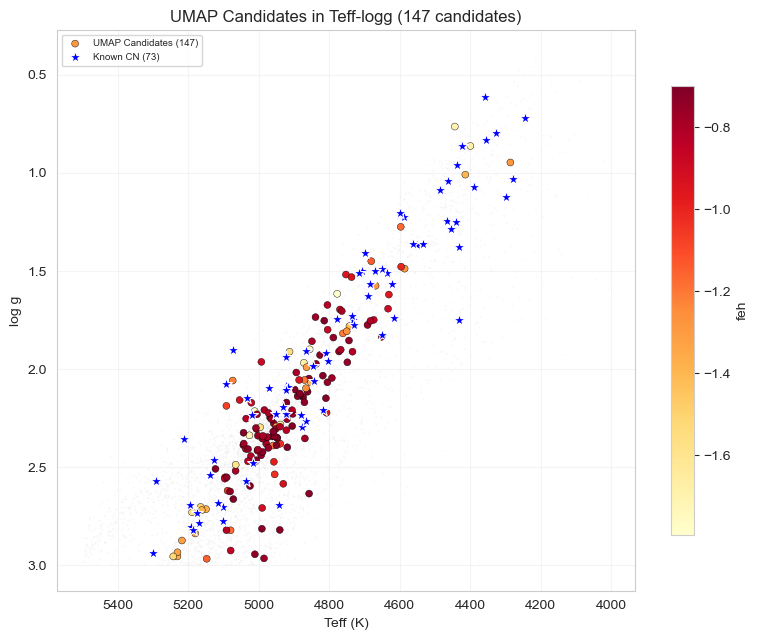

In [5]:
plt.figure(figsize=(8, 6.5))

rng = np.random.RandomState(42)
bg_sample = rng.choice(np.where(unlabeled_mask)[0], 4000, replace=False)
teff_all = stars_clean['teff'].values
logg_all = stars_clean['logg'].values
feh_all = stars_clean['feh'].values
# (a) All UMAP candidates in parameter space
plt.scatter(teff_all[bg_sample], logg_all[bg_sample], s=2, c='#e0e0e0', alpha=0.2,
           edgecolors='none', rasterized=True)
sc = plt.scatter(teff_all[candidates], logg_all[candidates],
                s=25, c=feh_all[candidates], cmap='YlOrRd',
                edgecolors='black', linewidth=0.3, zorder=2,label=f'UMAP Candidates ({len(candidates)})')
plt.scatter(teff_all[known_mask], logg_all[known_mask], s=80, c='blue', marker='*',
           edgecolors='white', linewidth=0.8, zorder=4, label=f'Known CN ({n_known})')
colorbar = plt.colorbar(sc, label='feh', shrink=0.8)
plt.xlabel('Teff (K)')
plt.ylabel('log g')
ax = plt.gca()
ax.invert_xaxis()
ax.invert_yaxis()
plt.title(f'UMAP Candidates in Teff-logg ({len(candidates)} candidates)')
plt.legend(fontsize=7); ax.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/umap_param_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. UMAP vs Label Spreading 候选体重叠分析

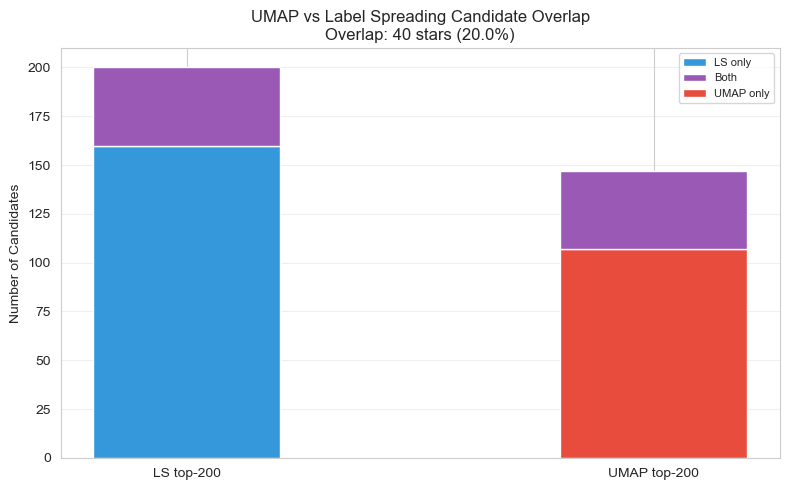

Overlap analysis (top-200 each):
  LS ∩ UMAP:  40 (20.0%)
  LS only:    160
  UMAP only:  107
  → UMAP adds 107 candidates not found by Label Spreading


In [6]:
# Try to load Label Spreading results
ls_path = _PROJECT_ROOT / 'LabelSpreading/LS_all_probs.csv'
if ls_path.exists():
    ls_df = pd.read_csv(ls_path)
    # Get LS top candidates (unlabeled, high z-score)
    ls_unl = ls_df[ls_df['label'] == -1].copy()
    ls_top200 = ls_unl.sort_values('ls_zscore', ascending=False).head(200)
    ls_uids = set(ls_top200['uid'].values)

    umap_uids = set(stars_clean.iloc[candidates]['uid'].values)

    overlap = ls_uids & umap_uids
    ls_only = ls_uids - umap_uids
    umap_only = umap_uids - ls_uids

    fig, ax = plt.subplots(figsize=(8, 5))
    methods = ['LS top-200', 'UMAP top-200']
    overlap_matrix = np.array([
        [len(ls_only), len(overlap)],
        [len(overlap), len(umap_only)],
    ])

    x = np.arange(len(methods))
    w = 0.4
    ax.bar(x[0], len(ls_only), w, color='#3498db', edgecolor='white', label='LS only')
    ax.bar(x[0], len(overlap), w, bottom=len(ls_only), color='#9b59b6', edgecolor='white', label='Both')
    ax.bar(x[1], len(umap_only), w, color='#e74c3c', edgecolor='white', label='UMAP only')
    ax.bar(x[1], len(overlap), w, bottom=len(umap_only), color='#9b59b6', edgecolor='white')

    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylabel('Number of Candidates')
    ax.set_title(f'UMAP vs Label Spreading Candidate Overlap\nOverlap: {len(overlap)} stars ({100*len(overlap)/200:.1f}%)')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    # plt.savefig(str(_PROJECT_ROOT / 'LabelSpreading/umap_vs_ls_overlap.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Overlap analysis (top-200 each):")
    print(f"  LS ∩ UMAP:  {len(overlap)} ({100*len(overlap)/200:.1f}%)")
    print(f"  LS only:    {len(ls_only)}")
    print(f"  UMAP only:  {len(umap_only)}")
    print(f"  → UMAP adds {len(umap_only)} candidates not found by Label Spreading")
else:
    print("Label Spreading results not found. Run LabelSpreading notebook first for overlap analysis.")


## 7. UMAP 候选体导出

In [7]:
out_cols = ['uid', 'ra', 'dec', 'teff', 'logg', 'feh', 'label', 'snru',
            'mag_ps_g', 'masked_cluster_id']

stars_export = stars_clean.iloc[candidates].copy()
# Add density
density_series = pd.Series(density, index=stars_clean.index)
stars_export['umap_density'] = density_series.iloc[candidates].values

# Sort by density descending
stars_export = stars_export.sort_values('umap_density', ascending=False)

out_cols = [c for c in out_cols if c in stars_export.columns] + ['umap_density']
export_df = stars_export[out_cols].head(200).copy()

outpath = str(_PROJECT_ROOT / 'LabelSpreading/UMAP_candidates.csv')
export_df.to_csv(outpath, index=False)

print(f"Candidates exported: {outpath}")
print(f"  Total: {len(export_df)}")
print(f"  Density range: {export_df['umap_density'].min():.4f} - {export_df['umap_density'].max():.4f}")
print(f"  Teff range: {export_df['teff'].min():.0f} - {export_df['teff'].max():.0f} K")
print(f"  logg range: {export_df['logg'].min():.2f} - {export_df['logg'].max():.2f}")


Candidates exported: d:\资料\2026大创\Lamost\LabelSpreading\UMAP_candidates.csv
  Total: 147
  Density range: 0.6396 - 2.6906
  Teff range: 4286 - 5242 K
  logg range: 0.76 - 2.97


## 8. 总结

### 核心发现

1. **UMAP 有效捕获流形结构** — 已知 CN 星在 UMAP 空间中形成可见的聚集区域，KDE 密度场将这些区域定量化

2. **密度导向候选体** — 基于已知 CN 星的核密度估计，在流形上识别未标记的高密度延伸区域

3. **与 Label Spreading 互补** — UMAP 从全局低维嵌入角度筛选，Label Spreading 从局部图传播角度筛选，两者找到的候选体部分重叠但不完全相同

### 局限

- UMAP 嵌入结果对参数敏感（n_neighbors, min_dist），不同参数可能产生不同的候选体排序
- KDE 在小样本（73 已知 CN）下的密度估计有偏差，特别是在密度较低的流形边缘
- 2-D 嵌入无法完全保留 700-D 光谱空间的所有结构信息
